In [1]:
import argparse
import datetime
import json
from copy import deepcopy
from typing import Type

import numpy as np
import os
import time
from pathlib import Path

import psutil
import torch
import torch.backends.cudnn as cudnn
import torchvision
from timm.utils import accuracy
from torch import nn, optim
from torch.utils.tensorboard import SummaryWriter
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import TensorDataset
import timm
import gc
# import nvidia_smi

# nvidia_smi.nvmlInit()
# assert timm.__version__ == "0.3.2" # version check
from timm.models.layers import trunc_normal_
from torchvision.datasets import STL10
from tqdm import tqdm

import util.misc as misc
from util.datasets import build_dataset_v2
from util.pos_embed import interpolate_pos_embed
from util.misc import NativeScalerWithGradNormCount as NativeScaler
from util.lars import LARS
from util.crop import RandomResizedCrop
import matplotlib.pyplot as plt
import models_vit
import abmilp
from collections import defaultdict
from tqdm import tqdm
import seaborn as sns

device = torch.device(
    ("cuda" if torch.cuda.is_available() else "cpu")
)

device

device(type='cpu')

In [2]:
imagenet_mean = torch.tensor([0.485, 0.456, 0.406])
imagenet_std = torch.tensor([0.229, 0.224, 0.225])

In [3]:
class args:
    input_size = 224
    dino_aug = False
    data_path = Path("img_custom/")
    model = "vit_base_patch16"
    finetune = "vit_base_patch16_224.mae"
    
_, dataset_custom = build_dataset_v2(args, is_pretrain=False)



data_loader_custom = torch.utils.data.DataLoader(
    dataset_custom,
    batch_size=128,
    num_workers=8,
    pin_memory=True,
    drop_last=False,
    shuffle=False
)

/home/przewiez/anaconda3/envs/pt2/lib/python3.12/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [4]:
model: models_vit.VisionTransformer = models_vit.__dict__[args.model](
        num_classes=1000,
    )

from timm.models.vision_transformer import _create_vision_transformer

model_kwargs = dict(patch_size=16, embed_dim=768, depth=12, num_heads=12)
checkpoint_model = _create_vision_transformer(args.finetune, pretrained=True, **model_kwargs).state_dict()

print("Load pre-trained checkpoint from: %s" % args.finetune)
state_dict = model.state_dict()
interpolate_pos_embed(model, checkpoint_model)
msg = model.load_state_dict(checkpoint_model, strict=False)

print(msg)

model = model.to(device)

vit_base_patch16_224.dino _IncompatibleKeys(missing_keys=['head.weight', 'head.bias'], unexpected_keys=[])
Load pre-trained checkpoint from: vit_base_patch16_224.mae
_IncompatibleKeys(missing_keys=['head.weight', 'head.bias', 'oracle.cls_token', 'oracle.pos_embed', 'oracle.patch_embed.proj.weight', 'oracle.patch_embed.proj.bias', 'oracle.blocks.0.norm1.weight', 'oracle.blocks.0.norm1.bias', 'oracle.blocks.0.attn.qkv.weight', 'oracle.blocks.0.attn.qkv.bias', 'oracle.blocks.0.attn.proj.weight', 'oracle.blocks.0.attn.proj.bias', 'oracle.blocks.0.norm2.weight', 'oracle.blocks.0.norm2.bias', 'oracle.blocks.0.mlp.fc1.weight', 'oracle.blocks.0.mlp.fc1.bias', 'oracle.blocks.0.mlp.fc2.weight', 'oracle.blocks.0.mlp.fc2.bias', 'oracle.blocks.1.norm1.weight', 'oracle.blocks.1.norm1.bias', 'oracle.blocks.1.attn.qkv.weight', 'oracle.blocks.1.attn.qkv.bias', 'oracle.blocks.1.attn.proj.weight', 'oracle.blocks.1.attn.proj.bias', 'oracle.blocks.1.norm2.weight', 'oracle.blocks.1.norm2.bias', 'oracle.bloc

In [5]:
abmilp_ckpt = Path("/shared/results/przewiez/uj/mae/timm_vit_base_patch16_224.mae/checkpoint-IN1K:abmilp:lars:2:16384:a:1:relu:none:none:patch:12.pth")
abmilp_name = abmilp_ckpt.name

_, _, _, _, _, _, depth, act, sa, cond, content, _ = abmilp_name.split(":")



abmilp_head = abmilp.ABMILPHead(
    dim=768,
    self_attention_apply_to=sa,
    activation=act,
    depth=int(depth),
    cond=cond,
    content=content,
    num_patches=196
)

seq = nn.Sequential(
    abmilp_head, 
    torch.nn.BatchNorm1d(model.head.in_features, affine=False, eps=1e-6),
    model.head
)

ckpt = torch.load(abmilp_ckpt, map_location="cpu")

seq.load_state_dict(ckpt["model"])
seq = seq.to(device)

# abmilp_name 
ckpt.keys()

dict_keys(['model', 'optimizer', 'epoch', 'scaler', 'args', 'test_stats'])

In [6]:
# token_selections.keys()
key_to_human = {
    "cls_attn_map_mean": "a) Average MAE\n$\mathtt{[cls]}$-patch attn.", #"MAE mean\n[cls] attention",
    "cls_attn_map_with_min_entropy": "b) Lowest-entropy MAE\n$\mathtt{[cls]}$-patch attn.",
    'central_patch_attention': "c) MAE central\npatch attn.",
    'dino_cls_attention_map': "d) Average DINO\n$\mathtt{[cls]}$-patch attn.",
    "abmilp_attn": "e) AbMILP",
}

key_to_human_custom = {
    k: " ".join(v.split(" ")[1:])
    for (k,v) in key_to_human.items() 
    if (
        v.startswith("a") or v.startswith("e")
    )
}
key_to_human_custom

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:6: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2222808/2263540006.py:3: SyntaxWarning: invalid escape sequence '\m'
  "cls_attn_map_mean": "a) Average MAE\n$\mathtt{[cls]}$-patch attn.", #"MAE mean\n[cls] attention",
/tmp/ipykernel_2222808/2263540006.py:4: SyntaxWarning: invalid escape sequence '\m'
  "cls_attn_map_with_min_entropy": "b) Lowest-entropy MAE\n$\mathtt{[cls]}$-patch attn.",
/tmp/ipykernel_2222808/2263540006.py:6: SyntaxWarning: invalid escape sequence '\m'
  'dino_cls_attention_map': "d) Average DINO\n$\mathtt{[cls]}$-patch attn.",


{'cls_attn_map_mean': 'Average MAE\n$\\mathtt{[cls]}$-patch attn.',
 'abmilp_attn': 'AbMILP'}

  0%|                                                     | 0/1 [00:00<?, ?it/s]

{'central_patch_attention': torch.Size([13, 196]), 'dino_cls_attention_map': torch.Size([13, 196]), 'cls_attn_map_with_min_entropy': torch.Size([13, 196]), 'cls_attn_map_mean': torch.Size([13, 196]), 'abmilp_attn': torch.Size([13, 196]), 'ncut_eigen': torch.Size([13, 196]), 'ncut_eigen_softmax': torch.Size([13, 196])}


100%|█████████████████████████████████████████████| 1/1 [00:46<00:00, 46.27s/it]


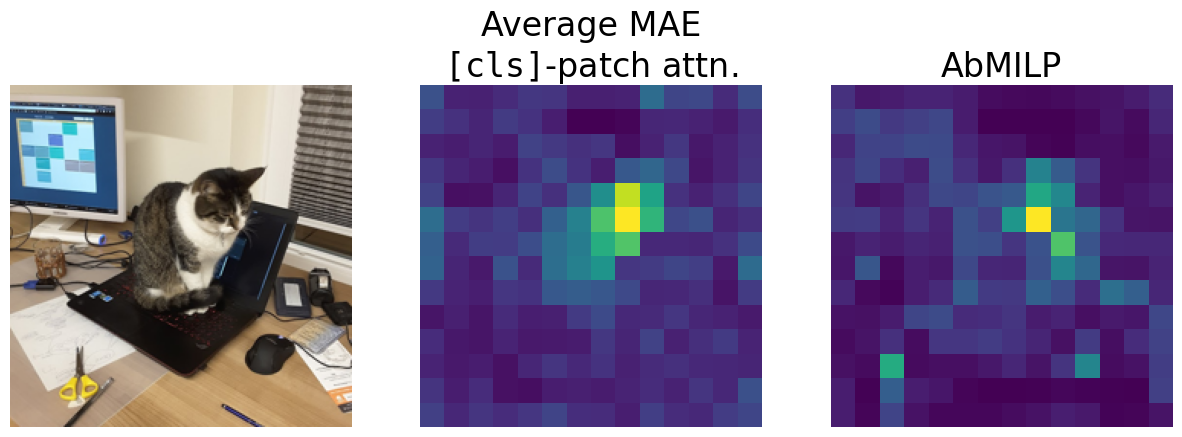

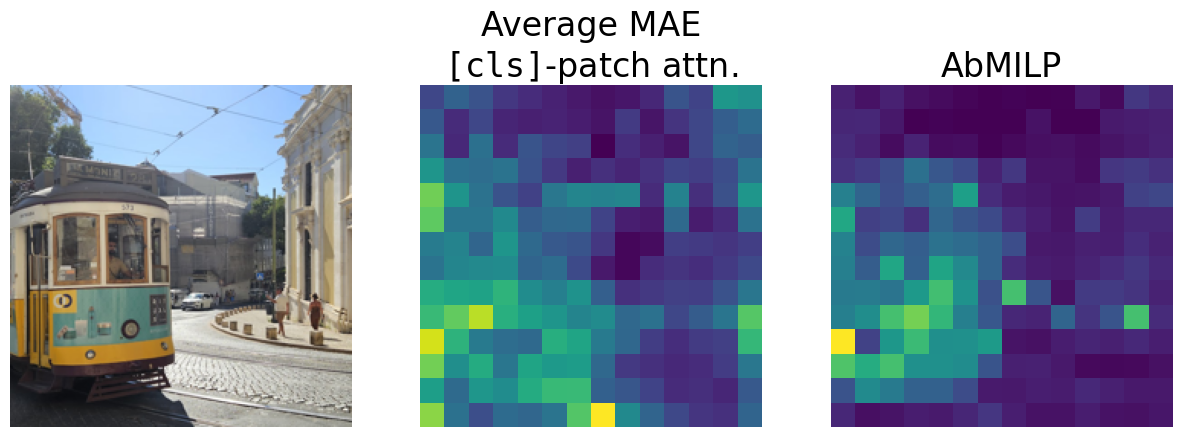

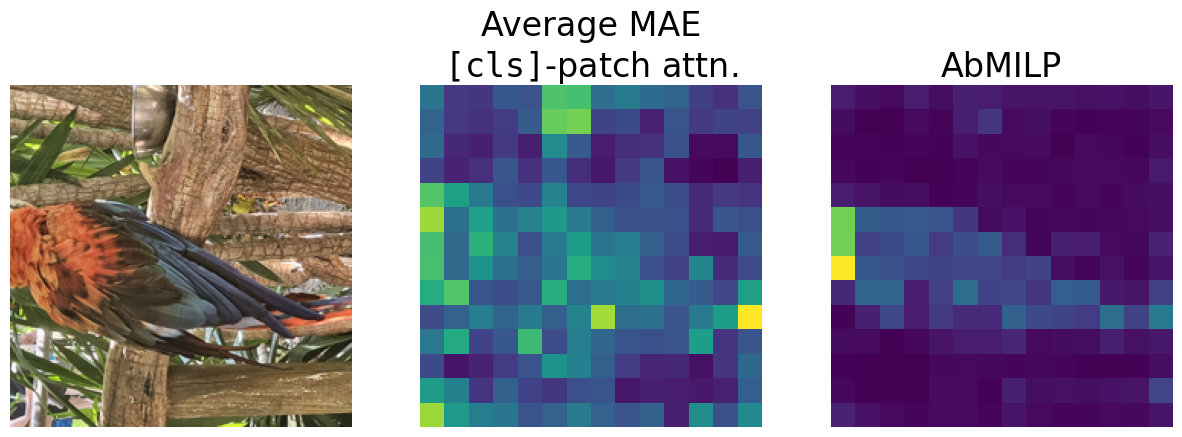

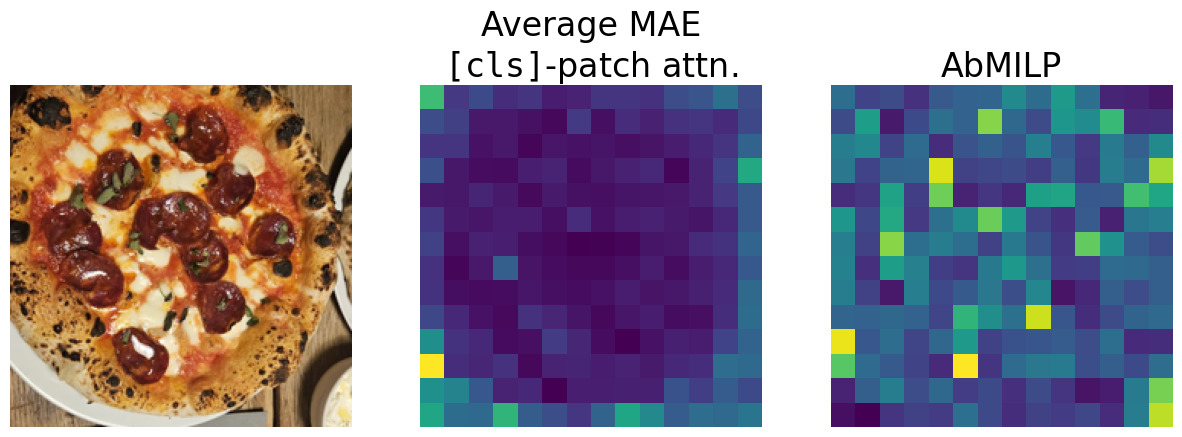

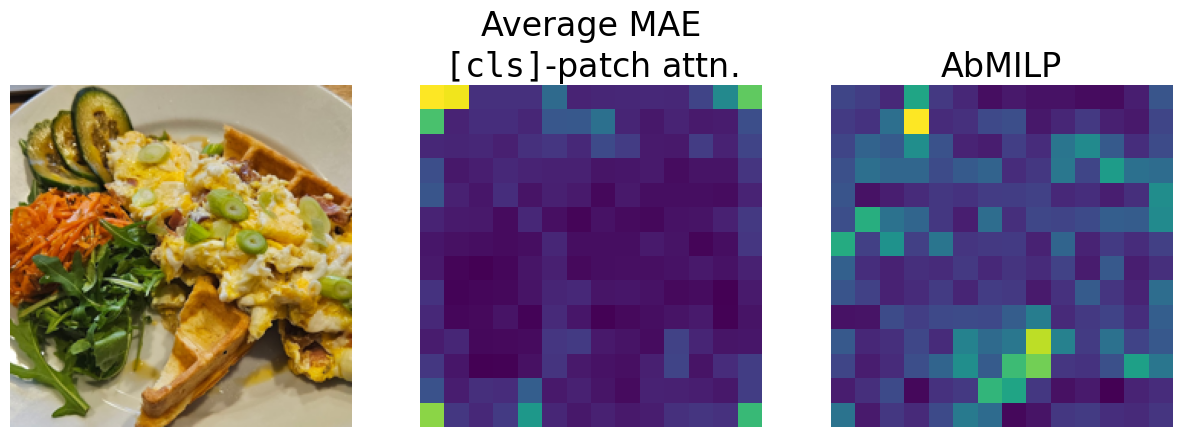

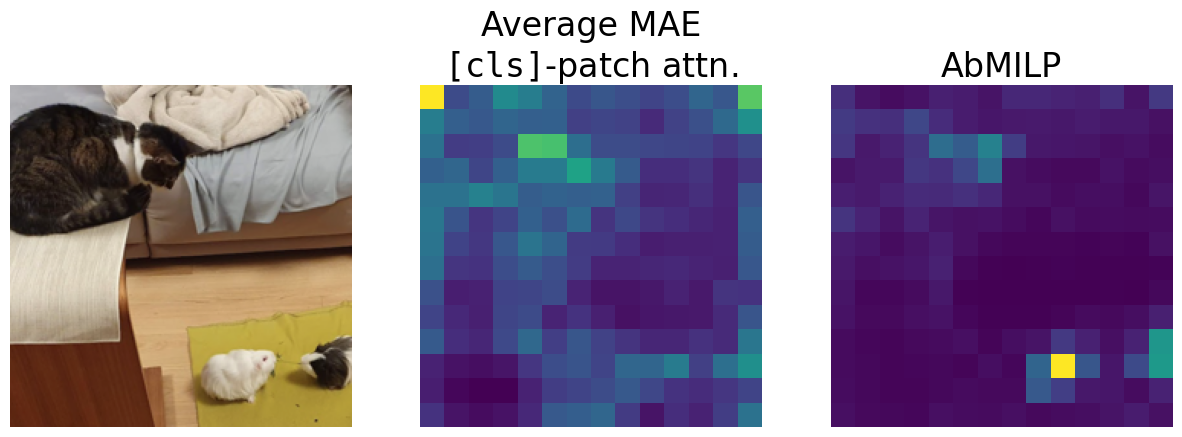

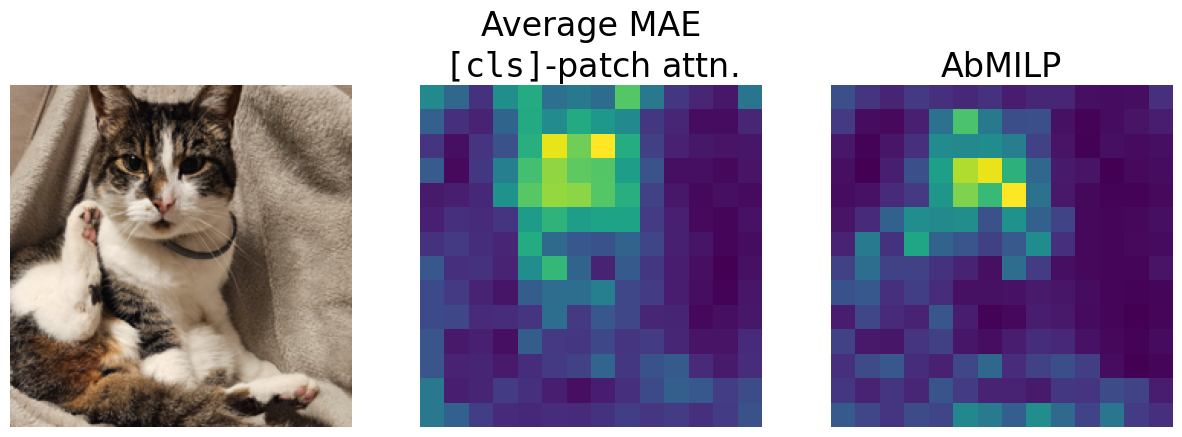

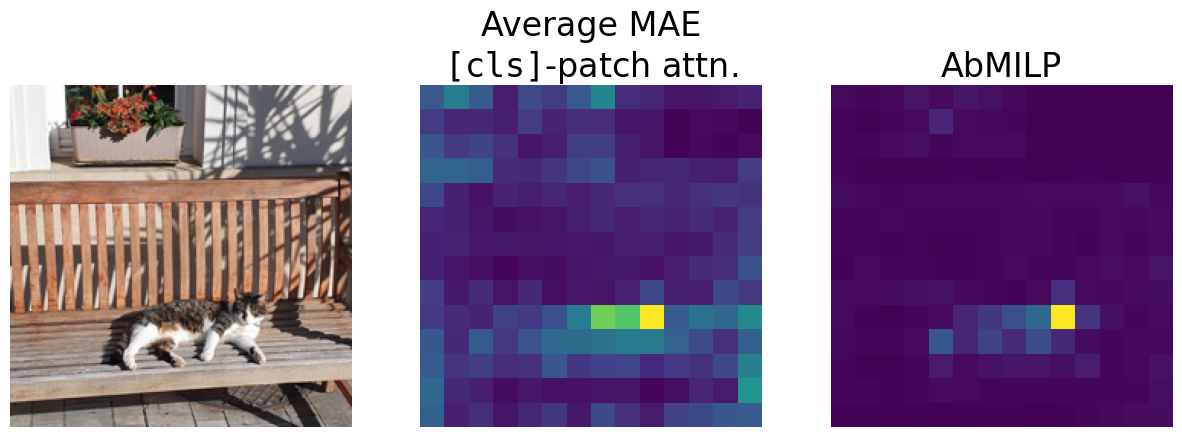

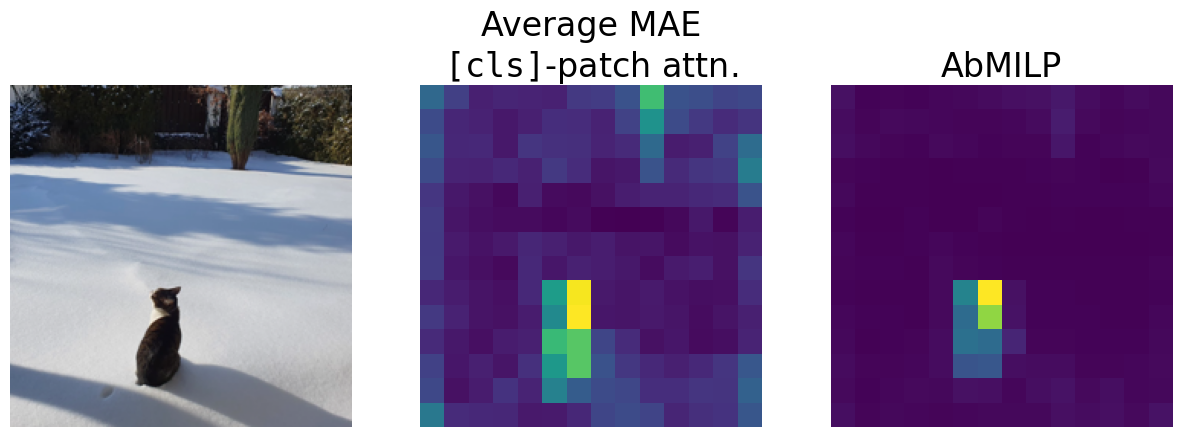

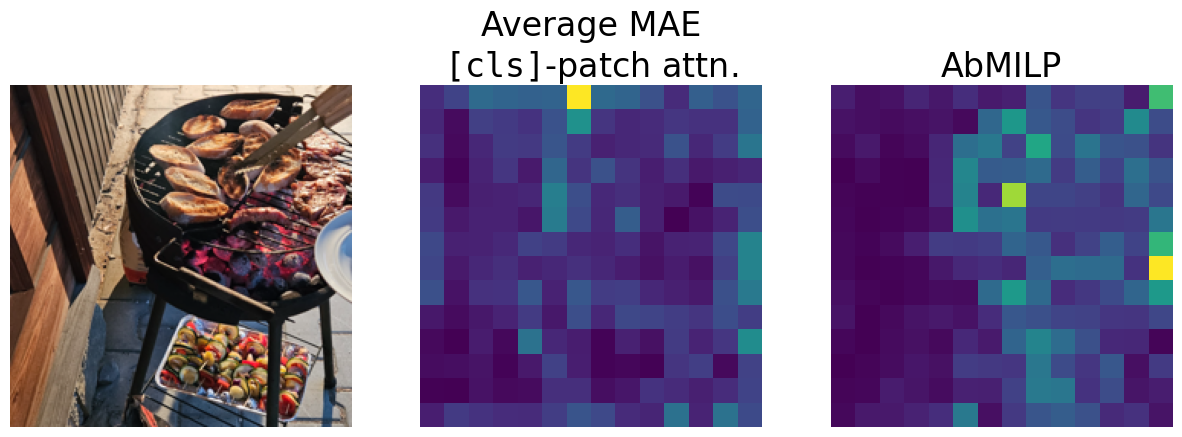

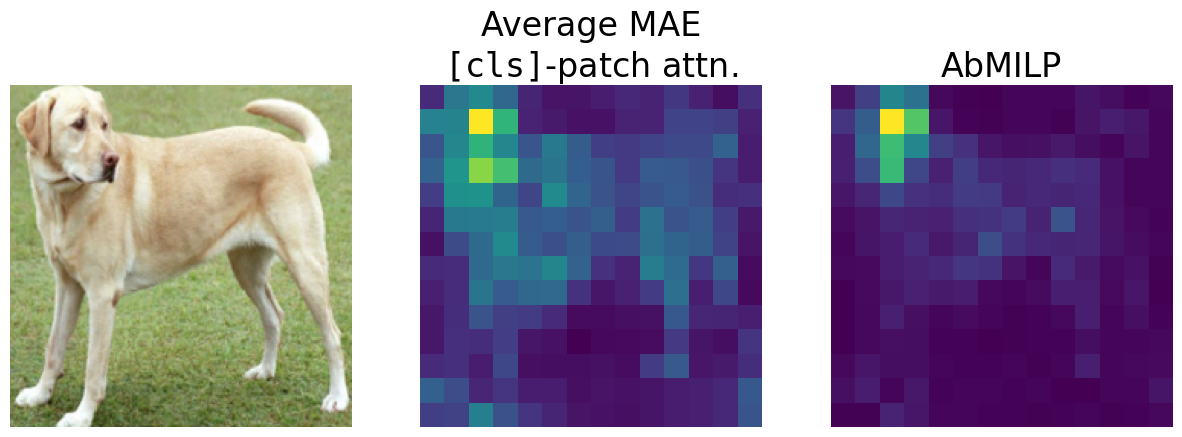

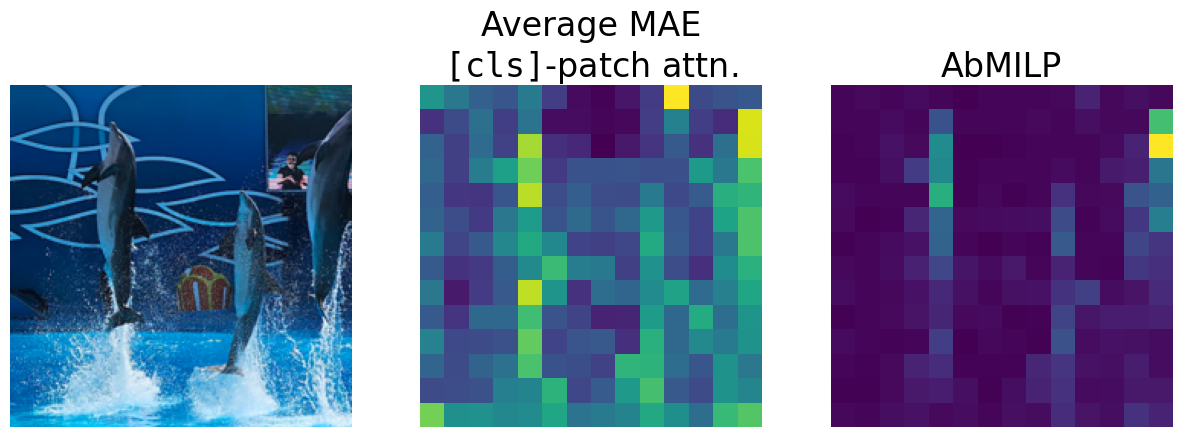

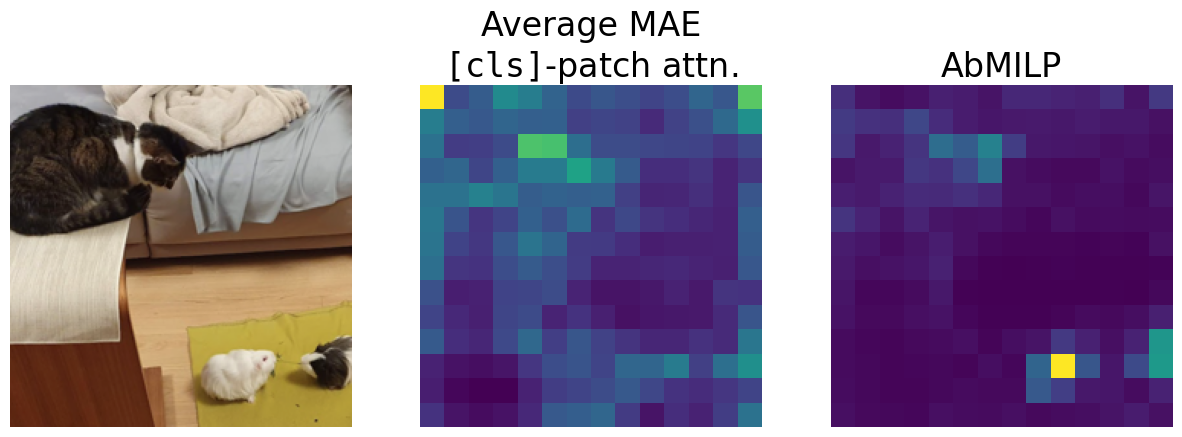

In [8]:

for x, _ in tqdm(data_loader_custom):
    token_selections = model.forward_features(x.to(device), return_features="toksec", abmilp_head=abmilp_head)
    
    print({k: v.shape for (k,v) in token_selections.items()})

    del token_selections["ncut_eigen_softmax"]
    
    N_ROWS = len(x)
    N_COLS = len(key_to_human_custom)+1
    ks = sorted(token_selections.keys())
    
    for i in range(N_ROWS):
        fig, ax = plt.subplots(nrows=1, ncols=N_COLS, figsize=(N_COLS*5, 1*5))

        ax[0].imshow(x[i].permute(1,2,0)* imagenet_std + imagenet_mean)
        
        for k, key in enumerate(key_to_human_custom.keys(), start=1):
            ax[k].imshow(
                token_selections[key][i].reshape(14,14).cpu()
            )
            ax[k].set_title(key_to_human_custom[key], fontsize=24)
            
    
        [a.axis("off") for a in ax]
        fig.show()
